<a href="https://colab.research.google.com/github/vikrampal12345/Practice_Revision_Machine_learning/blob/main/01_Practice_Standard_MinMaxScaler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score

In [94]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine(as_frame=True)
df = wine.frame
df.shape

(178, 14)

In [95]:
df.isnull().sum()     # no null data

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [96]:
df.head(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0


In [97]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [98]:
df['target'].value_counts()

,count
target,
1,71
0,59
2,48


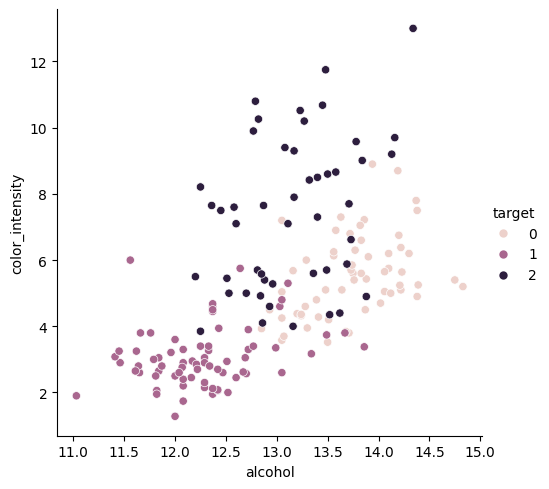

In [99]:
sns.relplot(data=df, x='alcohol', y='color_intensity', kind='scatter', hue='target')

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [101]:
df.corr()['alcohol']

,alcohol
alcohol,1.000000
malic_acid,0.094397
ash,0.211545
alcalinity_of_ash,-0.310235
magnesium,0.270798
total_phenols,0.289101
flavanoids,0.236815
nonflavanoid_phenols,-0.155929
proanthocyanins,0.136698
color_intensity,0.546364


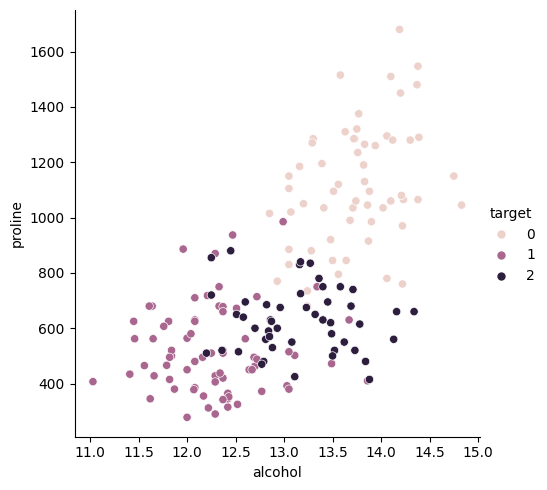

In [102]:
sns.relplot(data=df, x='alcohol', y='proline', kind='scatter', hue='target')

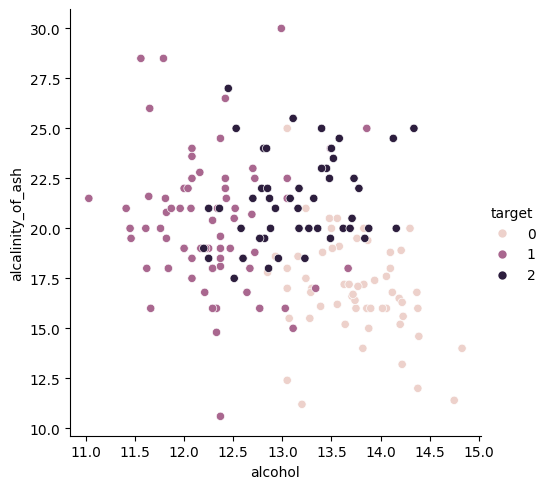

In [103]:
sns.relplot(data=df, x='alcohol', y='alcalinity_of_ash', hue='target', kind='scatter')

In [104]:
x=df.drop(columns=['target'])
y=df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=0)

In [105]:
X_train.shape, X_test.shape

((142, 13), (36, 13))

<Axes: xlabel='alcohol', ylabel='Density'>

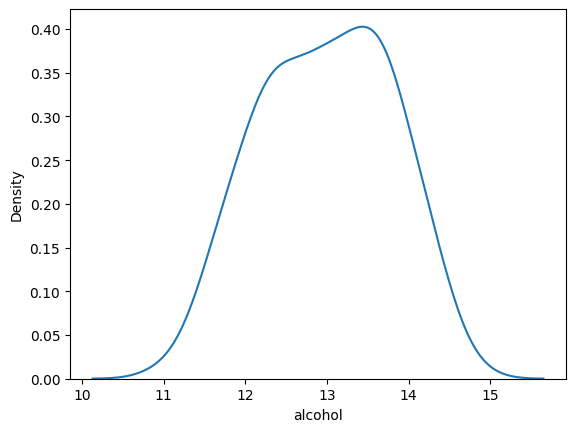

In [106]:
sns.kdeplot(X_train['alcohol'])

In [114]:
st = StandardScaler()
mx = MinMaxScaler()

X_train_scaled_st = st.fit_transform(X_train)  # standardScaler
X_train_scaled_mx = mx.fit_transform(X_train)  # minmaxscaler

X_test_scaled_st = mx.transform(X_test)
X_test_scaled_mx = st.transform(X_test)

X_test_scaled_st = pd.DataFrame(X_test_scaled_st, columns=X_train.columns)
X_test_scaled_mx = pd.DataFrame(X_test_scaled_mx, columns=X_train.columns)

X_train_scaled_st = pd.DataFrame(X_train_scaled_st, columns=X_train.columns)
X_train_scaled_mx = pd.DataFrame(X_train_scaled_mx, columns=X_train.columns)

In [115]:
X_train_scaled_st = pd.DataFrame(X_train_scaled_st, columns=X_train.columns)
X_train_scaled_mx = pd.DataFrame(X_train_scaled_mx, columns=X_train.columns)


Text(0.5, 1.0, 'after scaled')

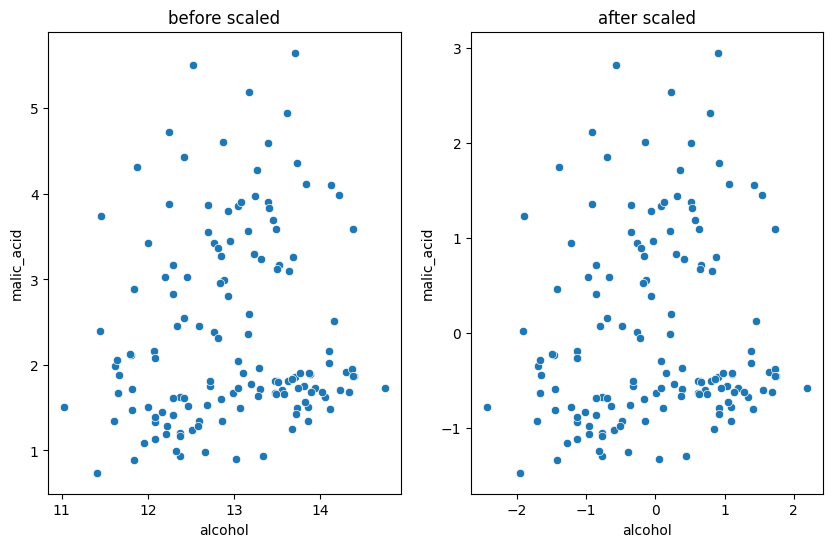

In [116]:
fig, ax = plt.subplots(1,2, figsize=(10,6))

sns.scatterplot(data=X_train, x='alcohol', y='malic_acid', ax=ax[0])
ax[0].set_title("before scaled")
sns.scatterplot(data=X_train_scaled_st, x='alcohol', y='malic_acid', ax=ax[1])
ax[1].set_title("after scaled")

In [119]:
lr = LogisticRegression(max_iter=5000) # standard
lr1 = LogisticRegression()  # normal
lr2 = LogisticRegression()  # minmaxscaler

lr.fit(X_train_scaled_st, y_train)
lr2.fit(X_train_scaled_mx, y_train)

lr1.fit(X_train, y_train)

y_pred_st = lr.predict(X_test_scaled_st)
y_pred_mx = lr2.predict(X_test_scaled_mx)

y_pred = lr1.predict(X_test)


print(accuracy_score(y_test, y_pred_st))
print(accuracy_score(y_test, y_pred_mx))

print(accuracy_score(y_test, y_pred))

0.3888888888888889
0.9444444444444444
0.9166666666666666


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [120]:
dt = DecisionTreeClassifier()
dt1 = DecisionTreeClassifier()
dt2 = DecisionTreeClassifier()

dt2.fit(X_train, y_train)


y_pred = dt2.predict(X_test)

accuracy_score(y_test, y_pred_st)

accuracy_score(y_test, y_pred_mx)

accuracy_score(y_test, y_pred)

0.9722222222222222